In [10]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Load Netflix dataset
df = pd.read_csv("netflix.csv")

# Display first 5 rows
print(df.head())

  show_id     type                  title         director  \
0      s1    Movie   Dick Johnson Is Dead  Kirsten Johnson   
1      s2  TV Show          Blood & Water              NaN   
2      s3  TV Show              Ganglands  Julien Leclercq   
3      s4  TV Show  Jailbirds New Orleans              NaN   
4      s5  TV Show           Kota Factory              NaN   

                                                cast        country  \
0                                                NaN  United States   
1  Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...   South Africa   
2  Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...            NaN   
3                                                NaN            NaN   
4  Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...          India   

           date_added  release_year rating   duration  \
0  September 25, 2021          2020  PG-13     90 min   
1  September 24, 2021          2021  TV-MA  2 Seasons   
2  September 24, 2021        

In [11]:
print("Shape of dataset:", df.shape)

print("\nColumn Information:")
print(df.info())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:")
print(df.duplicated().sum())

Shape of dataset: (8807, 12)

Column Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB
None

Missing Values:
show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating      

In [12]:
# Remove spaces from column names
df.columns = df.columns.str.strip()

# Convert column names to lowercase
df.columns = df.columns.str.lower()

print(df.columns)

Index(['show_id', 'type', 'title', 'director', 'cast', 'country', 'date_added',
       'release_year', 'rating', 'duration', 'listed_in', 'description'],
      dtype='object')


In [13]:
# Check duplicates
print("Duplicates before:", df.duplicated().sum())

# Remove duplicates
df.drop_duplicates(inplace=True)

print("Duplicates after:", df.duplicated().sum())

Duplicates before: 0
Duplicates after: 0


In [16]:
text_columns = [
    "show_id",
    "type",
    "title",
    "director",
    "cast",
    "country",
    "rating",
    "duration",
    "listed_in",
    "description"
]

for col in text_columns:
    df[col] = df[col].str.strip()

In [17]:
df["director"] = df["director"].replace(
    [np.nan, ""],
    "Unknown")

df["cast"] = df["cast"].replace(
    [np.nan, ""],
    "Unknown")

df["country"] = df["country"].replace(
    [np.nan, ""],
    "Unknown")

In [19]:
# Fill missing rating with most common rating
df["rating"] = df["rating"].fillna(
    df["rating"].mode()[0]
)

# Fill missing duration
df["duration"] = df["duration"].fillna("Unknown")

In [20]:
df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

print(df["date_added"].dtype)

datetime64[ns]


In [21]:
df["added_year"] = df["date_added"].dt.year

df["added_month"] = df["date_added"].dt.month

df["added_month_name"] = df["date_added"].dt.month_name()

In [23]:
df["duration_value"] = pd.to_numeric(
    df["duration"].str.extract(r"(\d+)")[0],
    errors="coerce"
)

print(df[["type", "duration", "duration_value"]].head(10))

      type   duration  duration_value
0    Movie     90 min            90.0
1  TV Show  2 Seasons             2.0
2  TV Show   1 Season             1.0
3  TV Show   1 Season             1.0
4  TV Show  2 Seasons             2.0
5  TV Show   1 Season             1.0
6    Movie     91 min            91.0
7    Movie    125 min           125.0
8  TV Show  9 Seasons             9.0
9    Movie    104 min           104.0


In [24]:
df["movie_duration"] = np.where(
    df["type"] == "Movie",
    df["duration_value"],
    np.nan)

df["tv_seasons"] = np.where(
    df["type"] == "TV Show",
    df["duration_value"],
    np.nan)

In [25]:
df["type"] = df["type"].str.title()

print(df["type"].value_counts())

type
Movie      6131
Tv Show    2676
Name: count, dtype: int64


In [26]:
print("Unique content types:")
print(df["type"].unique())

print("\nUnique ratings:")
print(df["rating"].unique())

print("\nRelease year range:")
print(df["release_year"].min(), "-", df["release_year"].max())

Unique content types:
['Movie' 'Tv Show']

Unique ratings:
['PG-13' 'TV-MA' 'PG' 'TV-14' 'TV-PG' 'TV-Y' 'TV-Y7' 'R' 'TV-G' 'G'
 'NC-17' '74 min' '84 min' '66 min' 'NR' 'TV-Y7-FV' 'UR']

Release year range:
1925 - 2021


In [27]:
current_year = 2026

df["valid_release_year"] = np.where(
    (df["release_year"] >= 1900) &
    (df["release_year"] <= current_year),
    True,
    False
)

print(df["valid_release_year"].value_counts())

valid_release_year
True    8807
Name: count, dtype: int64


In [28]:
df = df[df["valid_release_year"] == True]

df.drop(columns=["valid_release_year"], inplace=True)

In [29]:
print("\nMissing values after cleaning:")
print(df.isnull().sum())


Missing values after cleaning:
show_id                0
type                   0
title                  0
director               0
cast                   0
country                0
date_added            98
release_year           0
rating                 0
duration               0
listed_in              0
description            0
added_year            98
added_month           98
added_month_name      98
duration_value         3
movie_duration      2679
tv_seasons          6131
dtype: int64


In [30]:
print("\nFinal Dataset Shape:")
print(df.shape)

print("\nFinal Dataset Information:")
df.info()


Final Dataset Shape:
(8807, 18)

Final Dataset Information:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 18 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   show_id           8807 non-null   object        
 1   type              8807 non-null   object        
 2   title             8807 non-null   object        
 3   director          8807 non-null   object        
 4   cast              8807 non-null   object        
 5   country           8807 non-null   object        
 6   date_added        8709 non-null   datetime64[ns]
 7   release_year      8807 non-null   int64         
 8   rating            8807 non-null   object        
 9   duration          8807 non-null   object        
 10  listed_in         8807 non-null   object        
 11  description       8807 non-null   object        
 12  added_year        8709 non-null   float64       
 13  added_month      

In [31]:
df.to_csv(
    "netflix_cleaned.csv",
    index=False

print("Cleaned dataset saved successfully!")

Cleaned dataset saved successfully!


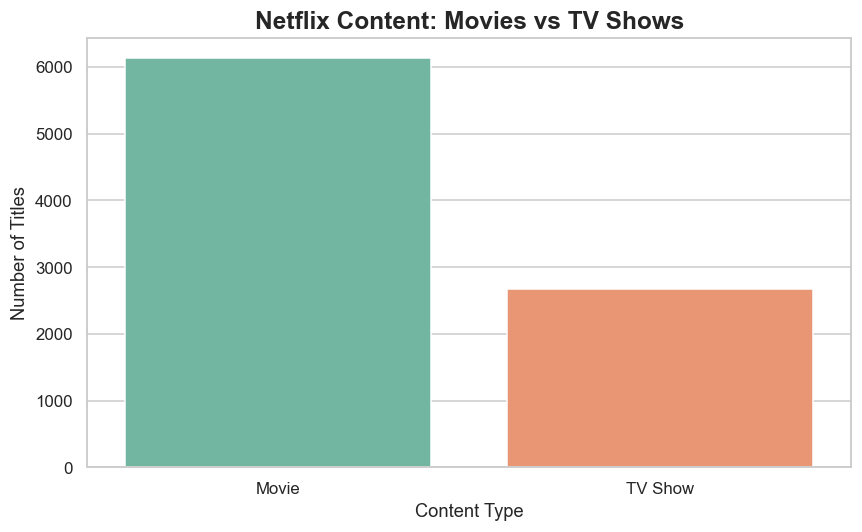

In [9]:

# =======================================
# 1. MOVIES VS TV SHOWS
# =======================================

plt.figure(figsize=(8, 5))

sns.countplot(
    data=df,
    x="type",
    hue="type",
    palette="Set2",
    legend=False
)

plt.title("Netflix Content: Movies vs TV Shows",
          fontsize=16, fontweight="bold")

plt.xlabel("Content Type")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()


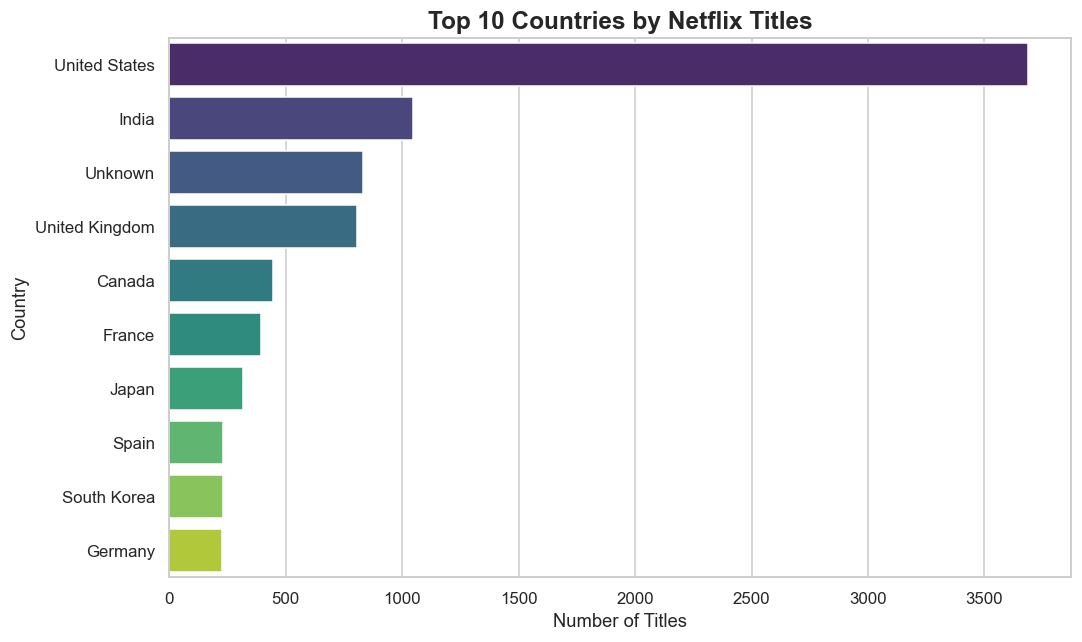

In [5]:
# =======================================
# 2. TOP 10 COUNTRIES
# =======================================

country_counts = (
    df["country"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=country_counts.values,
    y=country_counts.index,
    hue=country_counts.index,
    palette="viridis",
    legend=False
)

plt.title("Top 10 Countries by Netflix Titles",
          fontsize=16, fontweight="bold")

plt.xlabel("Number of Titles")
plt.ylabel("Country")

plt.tight_layout()
plt.show()


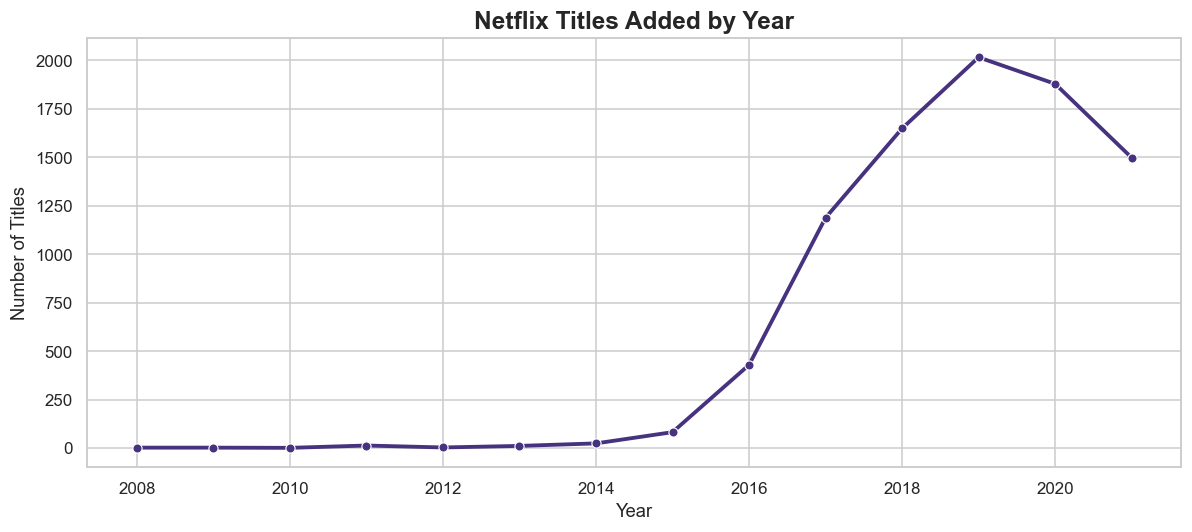

In [6]:
# =======================================
# 3. NETFLIX TITLES ADDED BY YEAR
# =======================================

df["date_added"] = pd.to_datetime(
    df["date_added"],
    errors="coerce"
)

yearly_added = (
    df["date_added"]
    .dt.year
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(11, 5))

sns.lineplot(
    x=yearly_added.index,
    y=yearly_added.values,
    marker="o",
    linewidth=2.5
)

plt.title("Netflix Titles Added by Year",
          fontsize=16, fontweight="bold")

plt.xlabel("Year")
plt.ylabel("Number of Titles")

plt.tight_layout()
plt.show()


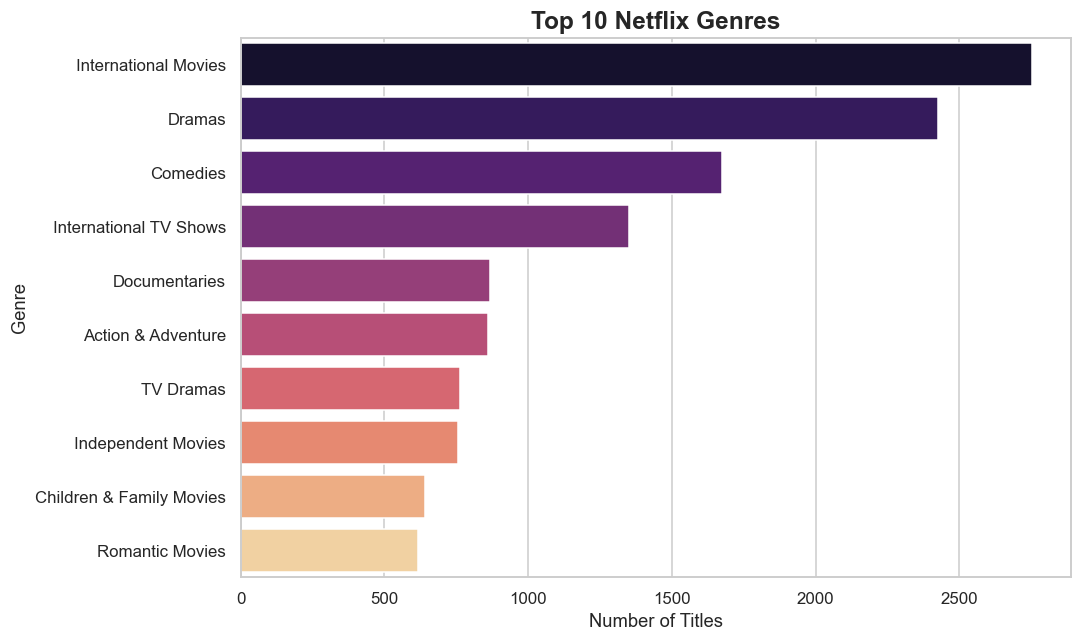

In [7]:
# =======================================
# 4. TOP 10 GENRES
# =======================================

genre_counts = (
    df["listed_in"]
    .dropna()
    .str.split(", ")
    .explode()
    .value_counts()
    .head(10)
)

plt.figure(figsize=(10, 6))

sns.barplot(
    x=genre_counts.values,
    y=genre_counts.index,
    hue=genre_counts.index,
    palette="magma",
    legend=False
)

plt.title("Top 10 Netflix Genres",
          fontsize=16, fontweight="bold")

plt.xlabel("Number of Titles")
plt.ylabel("Genre")

plt.tight_layout()
plt.show()


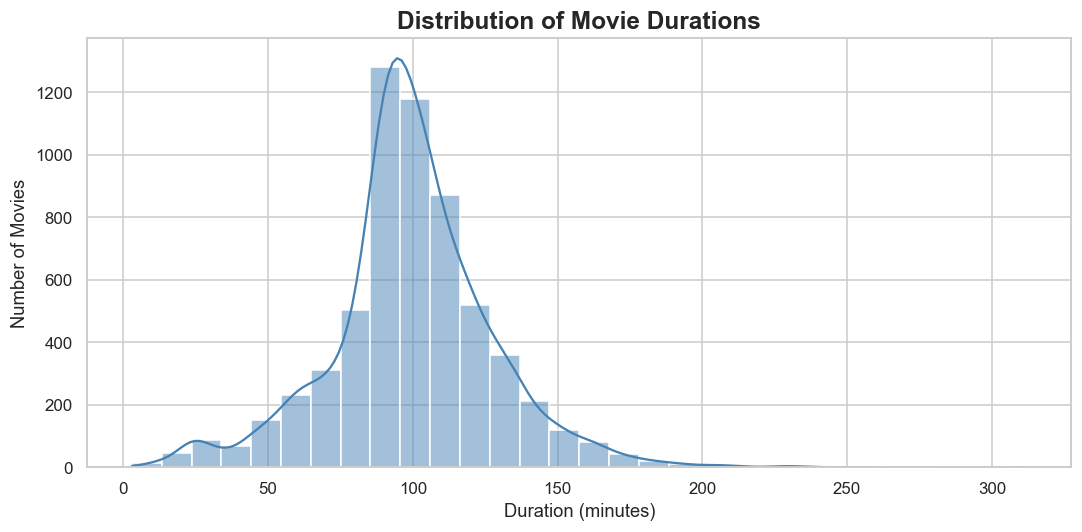

In [8]:
# =======================================
# 5. MOVIE DURATION DISTRIBUTION
# =======================================

movies = df[df["type"] == "Movie"].copy()

# Extract duration number
movies["duration_min"] = pd.to_numeric(
    movies["duration"]
    .astype(str)
    .str.extract(r"(\d+)")[0],
    errors="coerce"
)

# Remove missing values
movies = movies.dropna(subset=["duration_min"])

plt.figure(figsize=(10, 5))

sns.histplot(
    movies["duration_min"],
    bins=30,
    kde=True,
    color="steelblue"
)

plt.title("Distribution of Movie Durations",
          fontsize=16, fontweight="bold")

plt.xlabel("Duration (minutes)")
plt.ylabel("Number of Movies")

plt.tight_layout()
plt.show()